In [171]:
pip install pandas

In [172]:
pip install numpy

In [173]:
pip install matplotlib

In [174]:
pip install seaborn

In [175]:
# import python libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [176]:
# import csv file

df = pd.read_csv("airlines_reviews.csv",encoding='utf-8',encoding_errors='replace')


In [177]:
df.shape

(8100, 17)

In [178]:
df.head()

,Title,Name,Review Date,Airline,Verified,Reviews,Type of Traveller,Month Flown,Route,Class,Seat Comfort,Staff Service,Food & Beverages,Inflight Entertainment,Value For Money,Overall Rating,Recommended
0,Flight was amazing,Alison Soetantyo,2024-03-01,Singapore Airlines,True,Flight was amazing. The crew onboard this fl...,Solo Leisure,December 2023,Jakarta to Singapore,Business Class,4,4,4,4,4,9,yes
1,seats on this aircraft are dreadful,Robert Watson,2024-02-21,Singapore Airlines,True,Booking an emergency exit seat still meant h...,Solo Leisure,February 2024,Phuket to Singapore,Economy Class,5,3,4,4,1,3,no
2,Food was plentiful and tasty,S Han,2024-02-20,Singapore Airlines,True,Excellent performance on all fronts. I would...,Family Leisure,February 2024,Siem Reap to Singapore,Economy Class,1,5,2,1,5,10,yes
3,“how much food was available,D Laynes,2024-02-19,Singapore Airlines,True,Pretty comfortable flight considering I was f...,Solo Leisure,February 2024,Singapore to London Heathrow,Economy Class,5,5,5,5,5,10,yes
4,“service was consistently good”,A Othman,2024-02-19,Singapore Airlines,True,The service was consistently good from start ...,Family Leisure,February 2024,Singapore to Phnom Penh,Economy Class,5,5,5,5,5,10,yes


In [179]:
# check null values

pd.isnull(df).sum()

,0
Title,0
Name,0
Review Date,0
Airline,0
Verified,0
Reviews,0
Type of Traveller,0
Month Flown,0
Route,0
Class,0


In [180]:
# check duplicate values

df.duplicated().sum()

np.int64(0)

In [181]:
# Convets values to string and remove spaces

df['Verified'] = df['Verified'].astype(str).str.strip()

In [182]:
# Standardize values into only 2 categories
df['Verified'] = df['Verified'].apply(
    lambda x: 'Verified' if x == 'True' else 'Not Verified')

In [183]:
# Check text consistency

df['Recommended'].unique()

array(['yes', 'no'], dtype=object)

In [184]:
# Converting lowercase entries into a consistent format

df['Recommended'] = df['Recommended'].str.capitalize().str.strip()

In [185]:
df['Airline'] = df['Airline'].str.strip()

In [186]:
df['Verified'] = df['Verified'].str.capitalize()

In [187]:
# Convert Month Flown to proper datetime
df['Month Flown'] = pd.to_datetime( df['Month Flown'], format='%B %Y',  errors='coerce')


In [188]:
# Check Datatype

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8100 entries, 0 to 8099
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Title                   8100 non-null   object        
 1   Name                    8100 non-null   object        
 2   Review Date             8100 non-null   object        
 3   Airline                 8100 non-null   object        
 4   Verified                8100 non-null   object        
 5   Reviews                 8100 non-null   object        
 6   Type of Traveller       8100 non-null   object        
 7   Month Flown             8100 non-null   datetime64[ns]
 8   Route                   8100 non-null   object        
 9   Class                   8100 non-null   object        
 10  Seat Comfort            8100 non-null   int64         
 11  Staff Service           8100 non-null   int64         
 12  Food & Beverages        8100 non-null   int64   

In [189]:
# Convert datatype of Review date into datetime

df['Review Date'] = pd.to_datetime(df['Review Date'], errors='coerce')

In [190]:
# Check invalid values

df['Overall Rating'].describe()

,Overall Rating
count,8100.000000
mean,5.632469
std,3.523664
min,1.000000
25%,2.000000
50%,6.000000
75%,9.000000
max,10.000000


In [191]:
# Convert categorical columns

df['Airline'] = df['Airline'].astype('category')

In [192]:
df['Class'] = df['Class'].astype('category')

In [193]:
df['Type of Traveller'] = df['Type of Traveller'].astype('category')

In [194]:
# top airlines

top_airlines = df['Airline'].value_counts().head(5).index

In [195]:
# Filter dataset

df_top = df[df['Airline'].isin(top_airlines)]

# **Exploratory Data Analysis**

## **1. Average Rating by Airline**

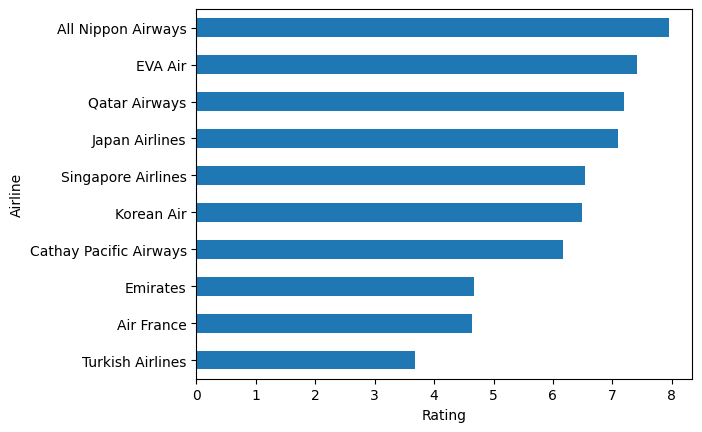

In [196]:
# plotting bar chart for average rating

avg_rating = df.groupby('Airline', observed=True)['Overall Rating'].mean().sort_values()

avg_rating.plot(kind='barh')
plt.xlabel("Rating")
plt.ylabel("Airline")
plt.show()

## **2. Airline Class Comparison**

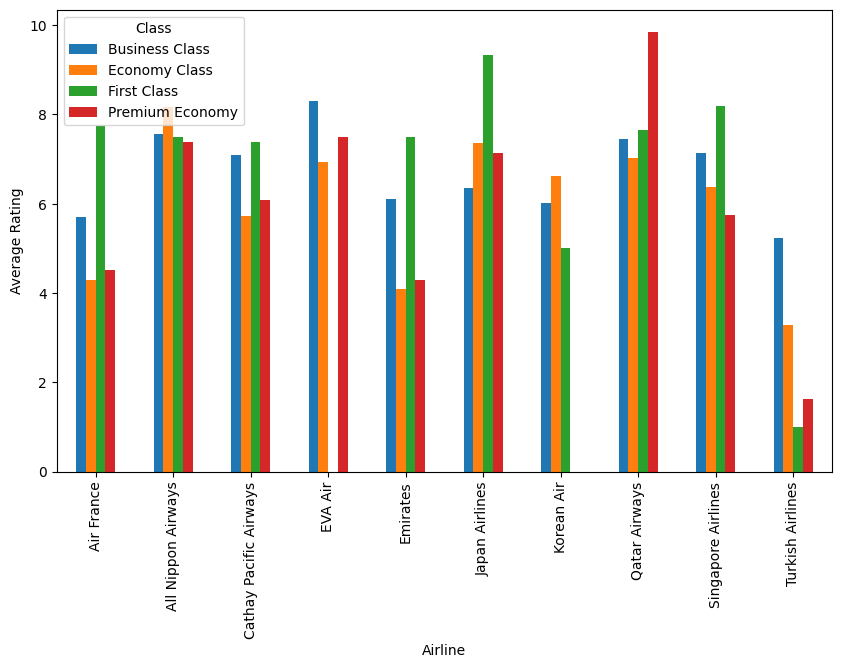

In [197]:
# plotting cluster bar chart for

class_airline = df.groupby(['Airline', 'Class'], observed=False)['Overall Rating'].mean().unstack()

class_airline.plot(kind='bar', figsize=(10,6))
plt.ylabel("Average Rating")
plt.show()

##**3. Recommendation**

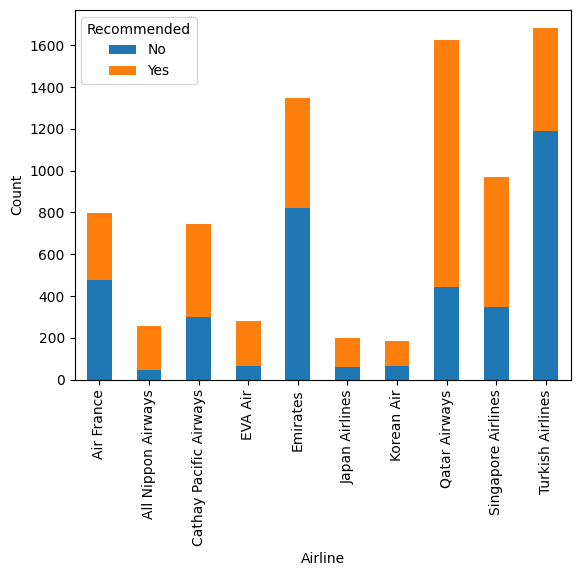

In [198]:
#plotting stack bar chart for airline reccomendation

pd.crosstab(df['Airline'], df['Recommended']).plot(kind='bar', stacked=True)
plt.xlabel("Airline")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

##**4. Top loved & hated airlines**

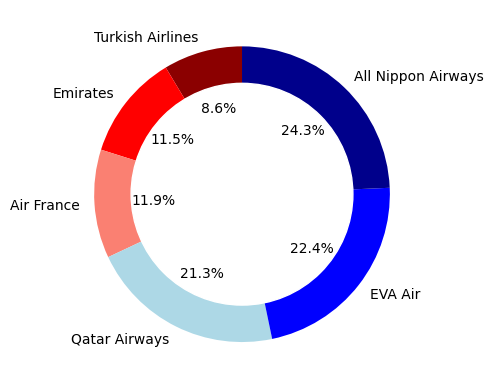

In [199]:
# plotting donut chart for top 3 loved and hated airlines based on recomendtion rating

df['Rec'] = df['Recommended'].map({'Yes':1,'No':0})

rec_rate = df.groupby('Airline', observed=True)['Rec'].mean().sort_values()
data = pd.concat([rec_rate.head(3), rec_rate.tail(3)])

plt.pie(data, labels=data.index, autopct='%1.1f%%',
        colors=['darkred','red','salmon','lightblue','blue','darkblue'], startangle=90)


plt.gca().add_artist(plt.Circle((0,0), 0.75, color='white'))

plt.show()

## **5. Verified vs Non-Verified Reviews**


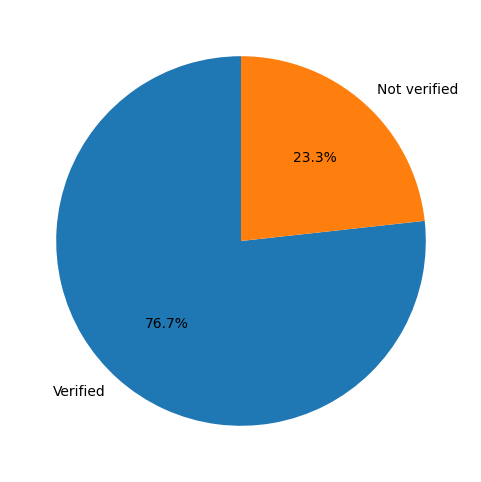

In [200]:
# Plotting pie chart for Review Verification Status

counts = df['Verified'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)

plt.show()

## **6. Airline-wise Customer Satisfaction Analysis**

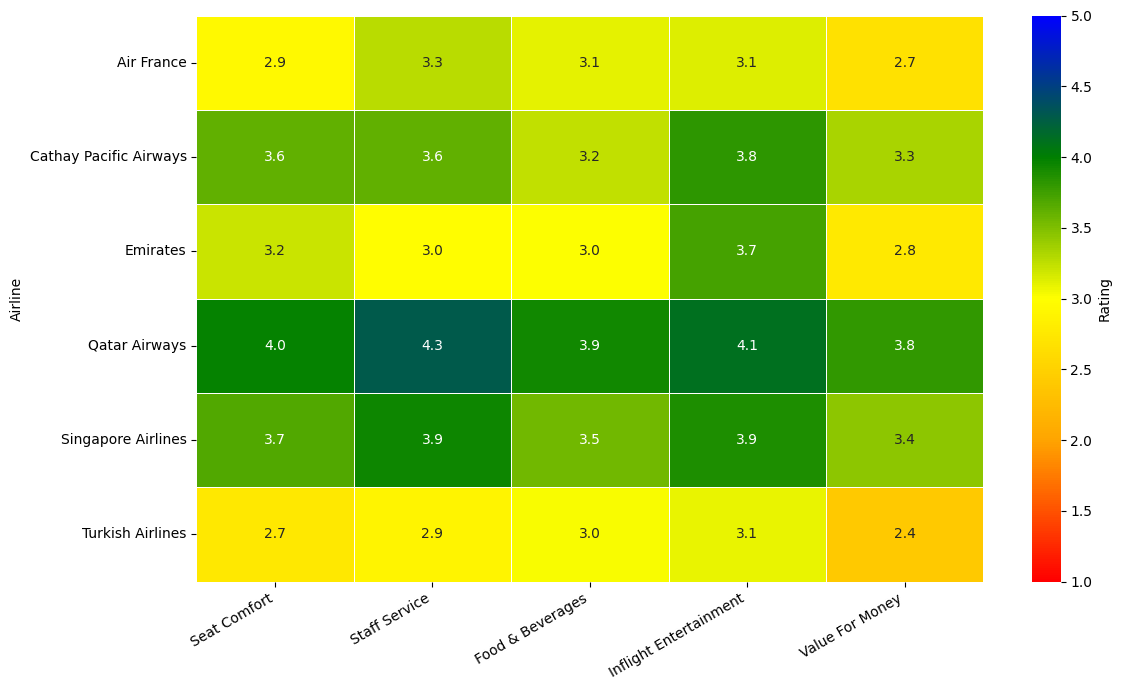

In [201]:
# plotting heatmap for airline perfornamce by features

from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list("rating_map",["red", "orange", "yellow", "green", "blue"])

plt.figure(figsize=(12, 7))

sns.heatmap(
    airline_features,
    annot=True,
    cmap=cmap,
    vmin=1, vmax=5,
    fmt=".1f",
    linewidths=0.5,
    mask=airline_features.isna(),
    cbar_kws={'label': 'Rating'}
)

plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# **Insights**

1. Some airlines perform better than others and receive higher ratings.
2. Passengers in Business and First class are more satisfied than those in Economy class.
3. Airlines providing good service receive more recommended reviews.
4. Some airlines are highly liked, while others are disliked due to poor service.
5. Value for money plays an important role in passenger ratings.
6. Verified reviews are more reliable than non-verified reviews.
7. Customer satisfaction depends on factors like seat comfort, staff behavior, and food quality.
8. Negative reviews often highlight issues like poor service or delays.
9. Low ratings indicate problems in overall service and passenger experience.

# **Conclusion**

Airline passenger satisfaction depends on service quality, comfort, and value for money. Airlines that deliver better experience receive higher ratings and recommendations, while poor service leads to negative feedback and lower satisfaction.